In [49]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [50]:
data=pd.read_csv("soccer_data.csv")

In [51]:
data.head(30)

,Home,Away,Home_Goals,Away_Goals
0,G-Olympus,Koban,2,3
1,Hirostar,Urawind,1,0
2,Nagomi,Shimizun,1,0
3,Savan Taurus,C-Osario,0,0
4,Sapporia,Iwana,0,0
5,Vegalia Senda,Kashirama,1,0
6,Kawasari Foresta,Ablihex Nimbus,1,0
7,Obiya Arcadia,FC Torii,0,1
8,Kashiwave,Yomoyama Mystic,3,3
9,Ablihex Nimbus,Obiya Arcadia,1,2


In [52]:
data.describe()

,Home_Goals,Away_Goals
count,2140.000000,2140.000000
mean,1.417757,1.253271
std,1.254916,1.133602
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [53]:
#Homeチームのゴール数の平均
me_Home=np.mean(data["Home_Goals"])
print("Homeチームのゴール数の平均：",me_Home)

#Awayチームのゴール数の平均
me_Away=np.mean(data["Away_Goals"])
print("Awayチームのゴール数の平均：",me_Away)

Homeチームのゴール数の平均： 1.4177570093457943
Awayチームのゴール数の平均： 1.253271028037383


In [54]:
data_Ur_Home=data.query("Home=='Urawind'")["Home_Goals"]
data_Ur_Away=data.query("Away=='Urawind'")["Away_Goals"]

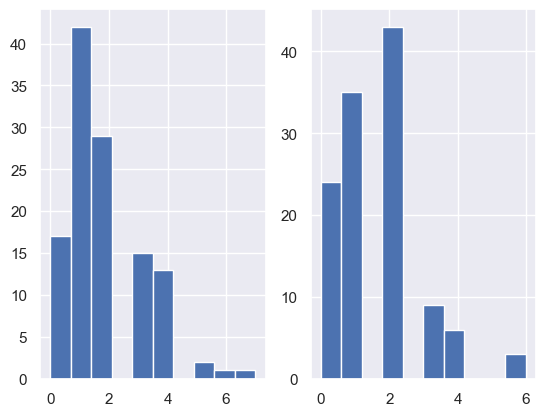

In [55]:
fig,axes=plt.subplots(1,2)
axes[0].hist(data_Ur_Home)
axes[1].hist(data_Ur_Away)
plt.show()

In [56]:
data_Ka_Home=data.query("Home=='Kashirama'")["Home_Goals"]
data_Ka_Away=data.query("Away=='Kashirama'")["Away_Goals"]

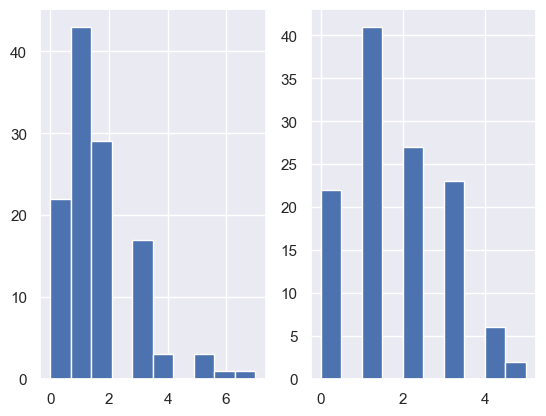

In [57]:
fig,axes=plt.subplots(1,2)
axes[0].hist(data_Ka_Home)
axes[1].hist(data_Ka_Away)
plt.show()

In [ ]:
#説明変数：Away_Goals、Home、Away
model_1=smf.glm("Home_Goals~Away_Goals+Home+Away",data=data,family=sm.families.Poisson()).fit()

In [85]:
#説明変数：Home と Away_Goals
model_2=smf.glm("Home_Goals~Away_Goals+Home",data=data,family=sm.families.Poisson()).fit()

In [70]:
print("Model-1",model_1.aic)
print("Model-2",model_2.aic)

Model-1 6448.85770313588
Model-2 6472.639085015406


In [141]:
print(model_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Home_Goals   No. Observations:                 2140
Model:                            GLM   Df Residuals:                     2087
Model Family:                 Poisson   Df Model:                           52
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3171.4
Date:                Thu, 02 Apr 2026   Deviance:                       2433.7
Time:                        19:56:52   Pearson chi2:                 2.13e+03
No. Iterations:                    20   Pseudo R-squ. (CS):             0.1027
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [114]:
#Home:Urawind、Away:Kashirama、Away_Goals:0の場合のHomeチームの得点の予測値
sampleData_1=pd.DataFrame({"Home":"Urawind","Away":"Kashirama","Away_Goals":0},index=[0])
sampleData_1

,Home,Away,Away_Goals
0,Urawind,Kashirama,0


In [115]:
#Home:Urawind、Away:Kashirama、Away_Goals:0の場合のHomeチームの得点の予測値
pred_1=model_1.predict(sampleData_1)
pred_1

0    1.575325
dtype: float64

In [116]:
#Home:Urawind、Away:Kashirama、Away_Goals:2の場合のHomeチームの得点の予測値
sampleData_2=pd.DataFrame({"Home":"Urawind","Away":"Kashirama","Away_Goals":2},index=[0])
sampleData_2

,Home,Away,Away_Goals
0,Urawind,Kashirama,2


In [117]:
#Home:Urawind、Away:Kashirama、Away_Goals:2の場合のHomeチームの得点の予測値
pred_2=model_1.predict(sampleData_2)
pred_2

0    1.730129
dtype: float64

In [134]:
#Home:Urawind、Away:Kashiramaの場合におけるKashiramaのAwayでの平均得点
me_Ka_Away=np.mean(data.query("Home=='Urawind'"and "Away=='Kashirama'")["Away_Goals"])
me_Ka_Away

np.float64(1.6363636363636365)

In [127]:
#上記平均得点をλとしてポアソン分布から乱数を100個生成
λ=me_Ka_Away
np.random.seed(1)
rvs_poisson=np.random.poisson(lam=λ,size=100)
rvs_poisson

array([2, 1, 0, 0, 1, 2, 1, 0, 2, 0, 1, 3, 1, 0, 0, 1, 3, 2, 0, 3, 1, 2,
       1, 0, 1, 1, 0, 1, 2, 2, 0, 2, 3, 0, 2, 3, 3, 2, 3, 3, 2, 0, 2, 3,
       0, 3, 0, 2, 4, 0, 0, 0, 2, 2, 1, 2, 1, 4, 0, 0, 0, 0, 0, 1, 1, 0,
       2, 1, 1, 3, 2, 0, 0, 2, 2, 2, 1, 0, 2, 1, 2, 3, 0, 4, 1, 5, 2, 4,
       0, 0, 1, 2, 0, 1, 3, 4, 2, 1, 3, 2])

In [130]:
#Awayチームの得点からHomeチームの得点を予測
Ur_Goals_list=[]
for i in rvs_poisson:
    sampleData_x=pd.DataFrame({"Home":"Urawind","Away":"Kashirama","Away_Goals":i},index=[0])
    pred_3=model_1.predict(sampleData_x)
    Ur_Goals_list.append(pred_3)
Ur_Goals_list2=np.array(Ur_Goals_list)

In [131]:
Ur_Goals_list2

array([[1.73012909],
       [1.6509136 ],
       [1.57532506],
       [1.57532506],
       [1.6509136 ],
       [1.73012909],
       [1.6509136 ],
       [1.57532506],
       [1.73012909],
       [1.57532506],
       [1.6509136 ],
       [1.81314557],
       [1.6509136 ],
       [1.57532506],
       [1.57532506],
       [1.6509136 ],
       [1.81314557],
       [1.73012909],
       [1.57532506],
       [1.81314557],
       [1.6509136 ],
       [1.73012909],
       [1.6509136 ],
       [1.57532506],
       [1.6509136 ],
       [1.6509136 ],
       [1.57532506],
       [1.6509136 ],
       [1.73012909],
       [1.73012909],
       [1.57532506],
       [1.73012909],
       [1.81314557],
       [1.57532506],
       [1.73012909],
       [1.81314557],
       [1.81314557],
       [1.73012909],
       [1.81314557],
       [1.81314557],
       [1.73012909],
       [1.57532506],
       [1.73012909],
       [1.81314557],
       [1.57532506],
       [1.81314557],
       [1.57532506],
       [1.730

In [135]:
x=Ur_Goals_list2>me_Ka_Away
x

array([[ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [

In [139]:
x.sum()

np.int64(70)

In [140]:
Ur_win=x.sum()/100
Ur_win

np.float64(0.7)

上記より、Urawindが勝つ確率は70％